# 3 基于模型的试验设计

> **图 3.1** 在二维区间 $[0, 1]^2$ 内三组包含 7 次运行的随机抽样设计。

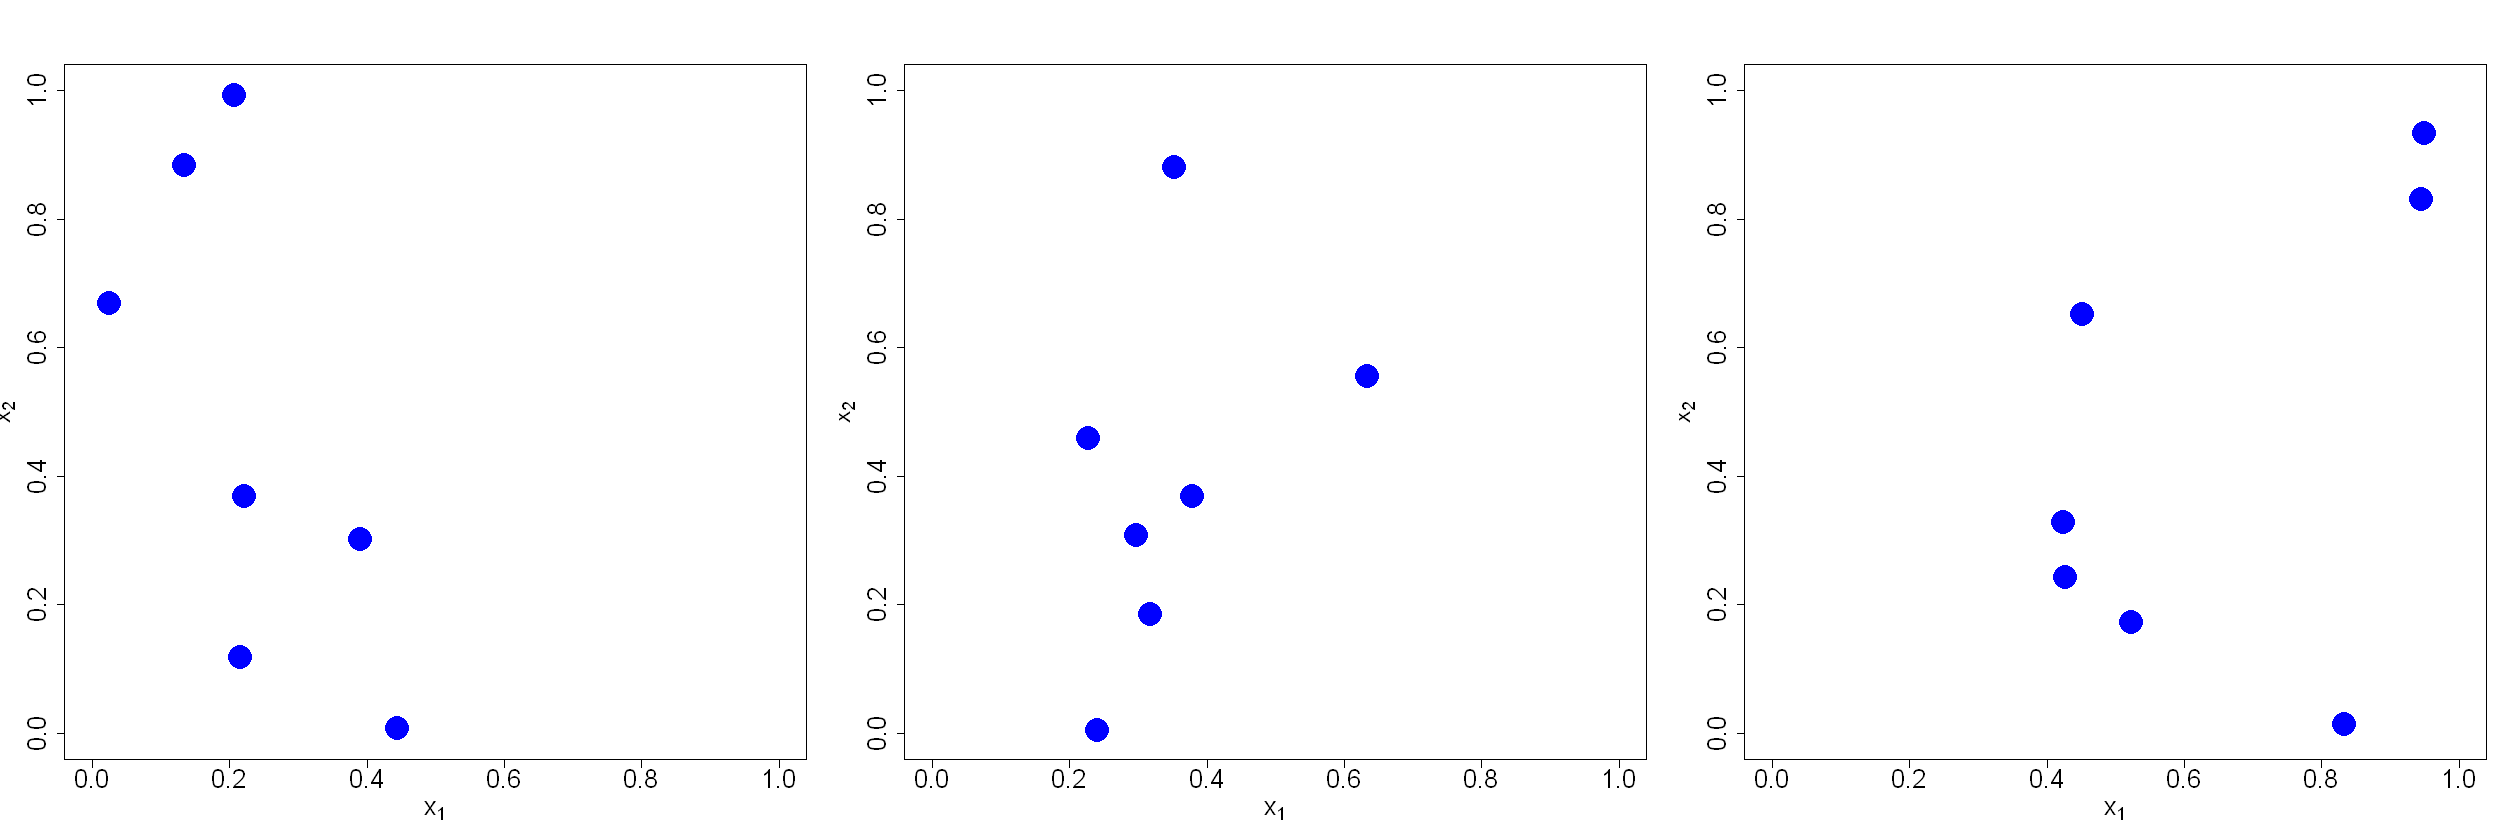

In [1]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/3.1-D.csv")){
  # <==== 绘图前计算：还原自 rexpdes/R/Ch3.R 图3.1 ====>
  p=2
  n=7
  ind=c(9,45,31)
  D1=matrix(0,nrow=n,ncol=p)
  D2=matrix(0,nrow=n,ncol=p)
  D3=matrix(0,nrow=n,ncol=p)
  for(i in 1:3){
    set.seed(ind[i])
    D=matrix(runif(n*p),nrow=n,ncol=p)
    if(i==1) D1=D
    if(i==2) D2=D
    if(i==3) D3=D
  }
  out1=cbind(D1,D2,D3)
  colnames(out1)=c(paste0("D1.",1:2),paste0("D2.",1:2),paste0("D3.",1:2))
  write.csv(out1,file="data/3.1-D.csv",row.names=FALSE)
}
# <==== 读回绘图 ====>
m.D=read.csv("data/3.1-D.csv")
D1=m.D[,paste0("D1.",1:2)]
D2=m.D[,paste0("D2.",1:2)]
D3=m.D[,paste0("D3.",1:2)]

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(D1,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=4,cex.lab=2,cex.axis=2)
plot(D2,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=4,cex.lab=2,cex.axis=2)
plot(D3,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=4,cex.lab=2,cex.axis=2)
par(mfrow=c(1,1))

> **图 3.2** 四种试验设计对应的均方根误差。若依托对应设计采集的数据拟合高斯过程模型，且模型相关函数取 $R(\Delta) = \exp(-\Delta^2/\theta^2)$、$\theta=0.1$，则纵坐标正比于置信区间宽度。

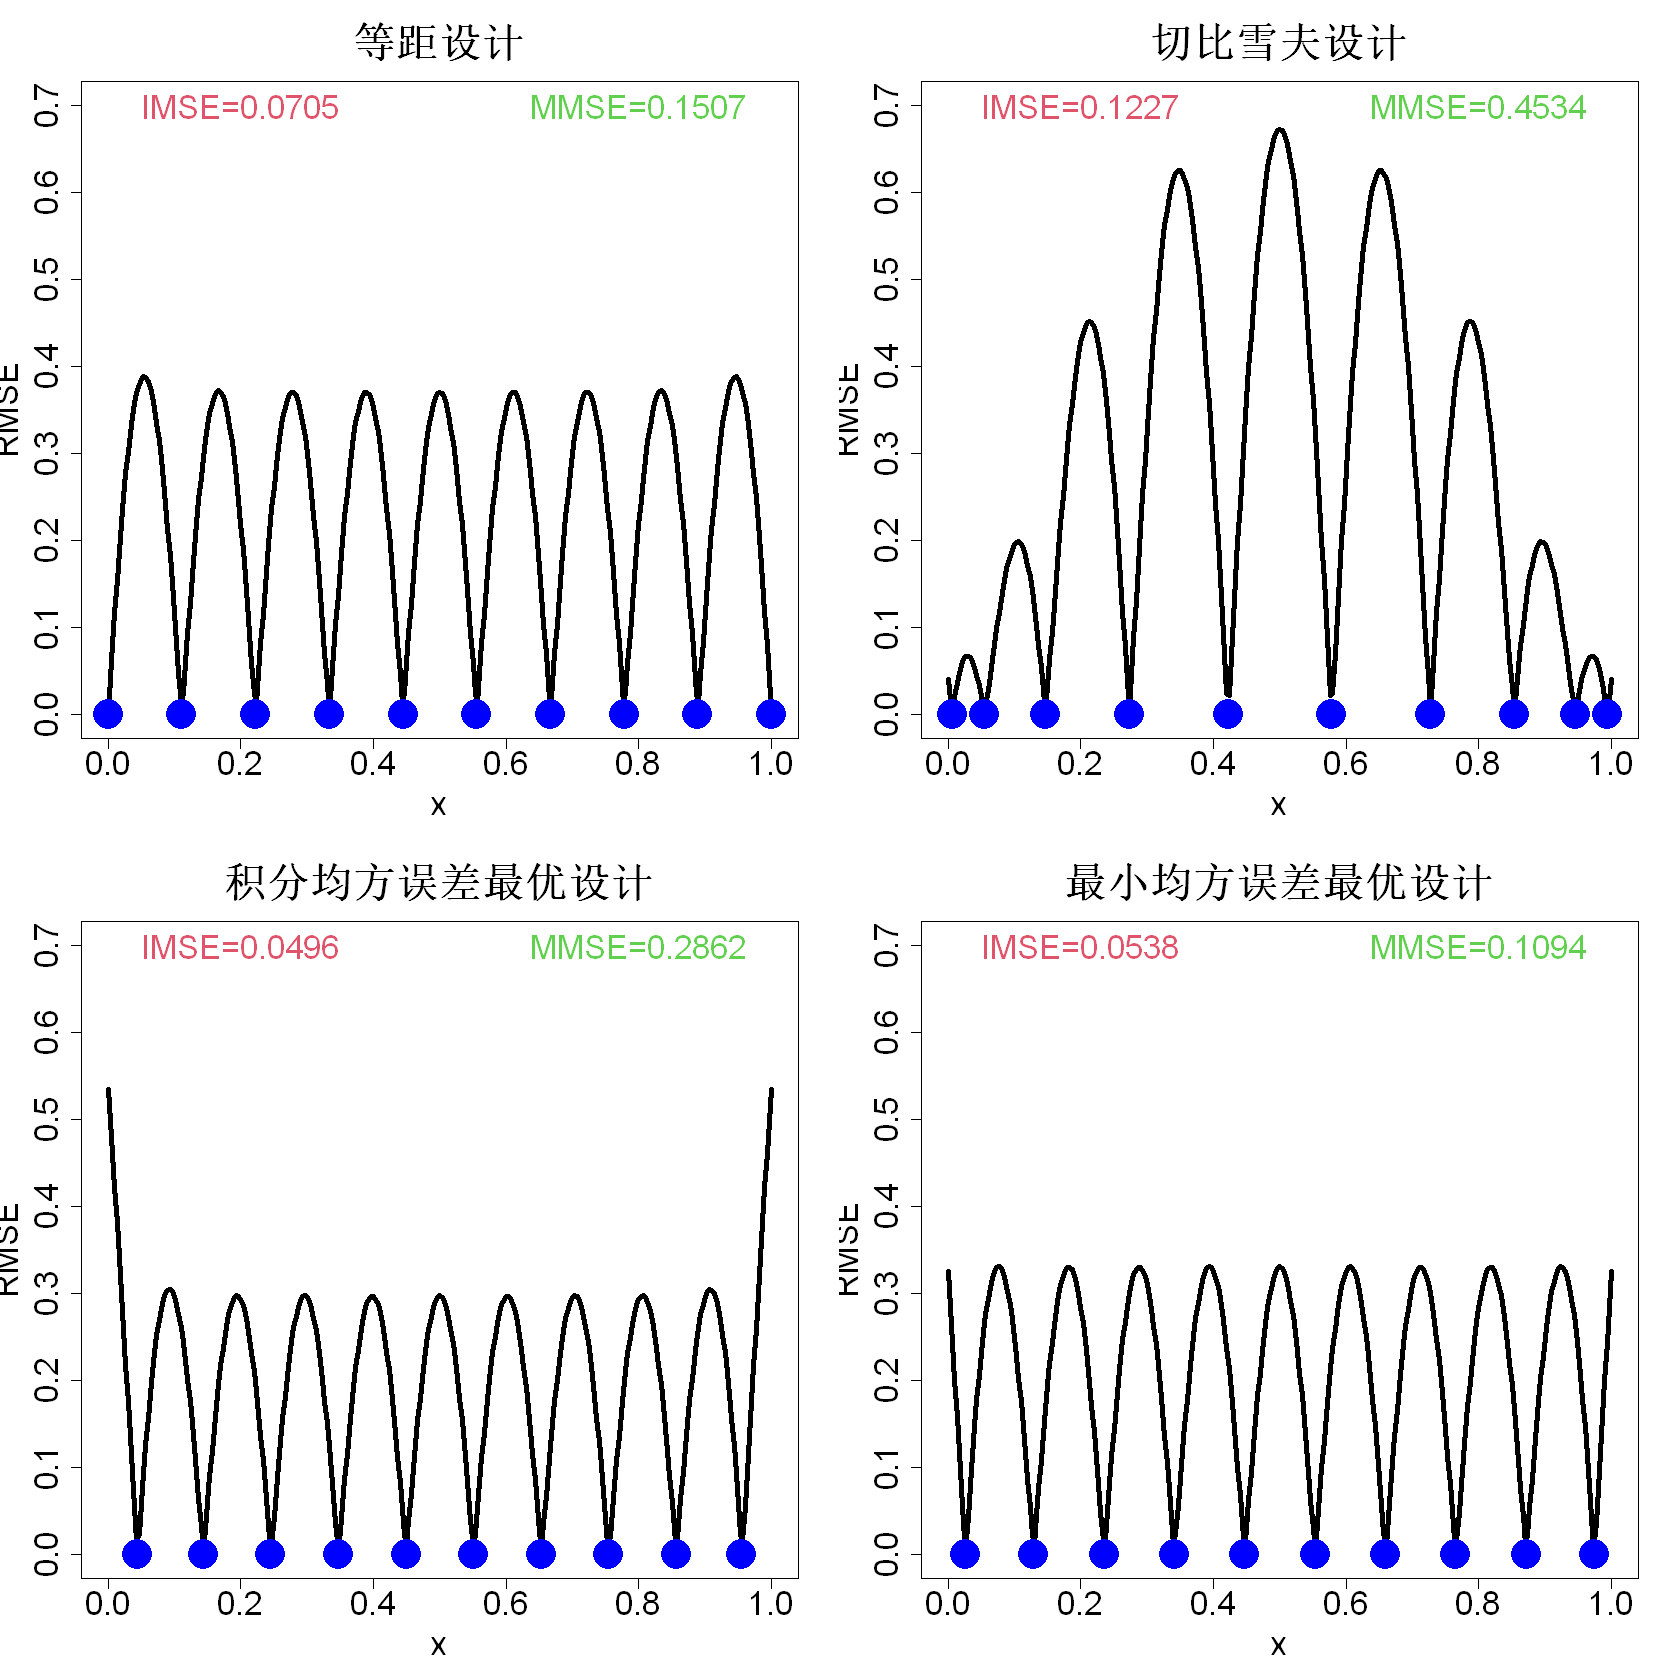

In [2]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/3.2-D.csv")||!file.exists("data/3.2-rmse.csv")||!file.exists("data/3.2-para.csv")){
  # <==== 绘图前计算：还原自 rexpdes/R/Ch3.R 图3.2 ====>
  n=10
  theta=.1
  r=function(x,D,theta) exp(-((x-D)/theta)^2)
  s=function(x,D,theta,L){
    a=forwardsolve(t(L),r(x,D,theta))
    return(sqrt(1-sum(a^2)))
  }
  imse=function(D,theta,n){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    L=chol(R+10^(-6)*diag(n))
    r=function(x) exp(-((x-D)/theta)^2)
    s=function(x){
      a=forwardsolve(t(L),r(x))
      return(1-sum(a^2))
    }
    val=integrate(Vectorize(s),0,1,abs.tol=10^(-10))$val
    return(val)
  }
  mmse=function(D,theta,n){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    L=chol(R+10^(-6)*diag(n))
    r=function(x) exp(-((x-D)/theta)^2)
    s=function(x){
      a=forwardsolve(t(L),r(x))
      return(1-sum(a^2))
    }
    test=seq(0,1,length=1001)
    val=apply(cbind(test),1,s)
    return(max(val))
  }
  N=301
  test=seq(0,1,length=N)
  # D1：等距设计
  D=D1=((1:n)-1)/(n-1)
  E=as.matrix(dist(D1))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa1=apply(cbind(test),1,function(xi) s(xi,D1,theta,L))
  imse1=imse(D1,theta,n)
  mmse1=mmse(D1,theta,n)
  # D2：切比雪夫设计
  d=cos((2*(1:n)-1)/(2*n)*pi)
  D=D2=(d+1)/2
  E=as.matrix(dist(D2))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa2=apply(cbind(test),1,function(xi) s(xi,D2,theta,L))
  imse2=imse(D2,theta,n)
  mmse2=mmse(D2,theta,n)
  # D3：IMSE 最优设计
  D0=((1:n)-.5)/n
  a=optim(D0,imse,theta=theta,n=n,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D=D3=a$par
  E=as.matrix(dist(D3))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa3=apply(cbind(test),1,function(xi) s(xi,D3,theta,L))
  imse3=imse(D3,theta,n)
  mmse3=mmse(D3,theta,n)
  # D4：MMSE 最优设计
  a=optim(D0,mmse,theta=theta,n=n,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D=D4=a$par
  E=as.matrix(dist(D4))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa4=apply(cbind(test),1,function(xi) s(xi,D4,theta,L))
  imse4=imse(D4,theta,n)
  mmse4=mmse(D4,theta,n)
  out1=cbind(D1,D2,D3,D4)
  colnames(out1)=c("D1","D2","D3","D4")
  write.csv(out1,file="data/3.2-D.csv",row.names=FALSE)
  out2=cbind(test,sa1,sa2,sa3,sa4)
  colnames(out2)=c("test","sa1","sa2","sa3","sa4")
  write.csv(out2,file="data/3.2-rmse.csv",row.names=FALSE)
  out3=cbind(theta,imse1,imse2,imse3,imse4,mmse1,mmse2,mmse3,mmse4)
  colnames(out3)=c("theta","IMSE1","IMSE2","IMSE3","IMSE4","MMSE1","MMSE2","MMSE3","MMSE4")
  write.csv(out3,file="data/3.2-para.csv",row.names=FALSE)
}
# <==== 读回绘图 ====>
df_D=read.csv("data/3.2-D.csv")
D1=df_D$D1;D2=df_D$D2;D3=df_D$D3;D4=df_D$D4
RMSE=read.csv("data/3.2-rmse.csv")
test=RMSE$test;sa1=RMSE$sa1;sa2=RMSE$sa2;sa3=RMSE$sa3;sa4=RMSE$sa4
para=read.csv("data/3.2-para.csv")
theta=para$theta
IMSE1=para$IMSE1;IMSE2=para$IMSE2;IMSE3=para$IMSE3;IMSE4=para$IMSE4
MMSE1=para$MMSE1;MMSE2=para$MMSE2;MMSE3=para$MMSE3;MMSE4=para$MMSE4

options(repr.plot.width=14,repr.plot.height=14)
par(mfrow=c(2,2))
plot(test,sa1,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),lwd=4,cex.lab=2,cex.axis=2,main="等距设计",cex.main=2.5)
points(cbind(D1,0),pch=16,col="blue",cex=4)
text(.2,.7,paste0("IMSE=",round(IMSE1,4)),cex=2,col=2)
text(.8,.7,paste0("MMSE=",round(MMSE1,4)),cex=2,col=3)
plot(test,sa2,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),lwd=4,cex.lab=2,cex.axis=2,main="切比雪夫设计",cex.main=2.5)
points(cbind(D2,0),pch=16,col="blue",cex=4)
text(.2,.7,paste0("IMSE=",round(IMSE2,4)),cex=2,col=2)
text(.8,.7,paste0("MMSE=",round(MMSE2,4)),cex=2,col=3)
plot(test,sa3,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),lwd=4,cex.lab=2,cex.axis=2,main="积分均方误差最优设计",cex.main=2.5)
points(cbind(D3,0),pch=16,col="blue",cex=4)
text(.2,.7,paste0("IMSE=",round(IMSE3,4)),cex=2,col=2)
text(.8,.7,paste0("MMSE=",round(MMSE3,4)),cex=2,col=3)
plot(test,sa4,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),lwd=4,cex.lab=2,cex.axis=2,main="最小均方误差最优设计",cex.main=2.5)
points(cbind(D4,0),pch=16,col="blue",cex=4)
text(.2,.7,paste0("IMSE=",round(IMSE4,4)),cex=2,col=2)
text(.8,.7,paste0("MMSE=",round(MMSE4,4)),cex=2,col=3)
par(mfrow=c(1,1))

> **图 3.3** 图 3.2 中四种设计方案在积分均方误差（IMSE）与最小最大均方误差（MMSE）指标下的相对效率。将参数 $\theta$ 固定为 0.1，即可求得分别适配积分均方误差、最小最大均方误差的最优设计方案。

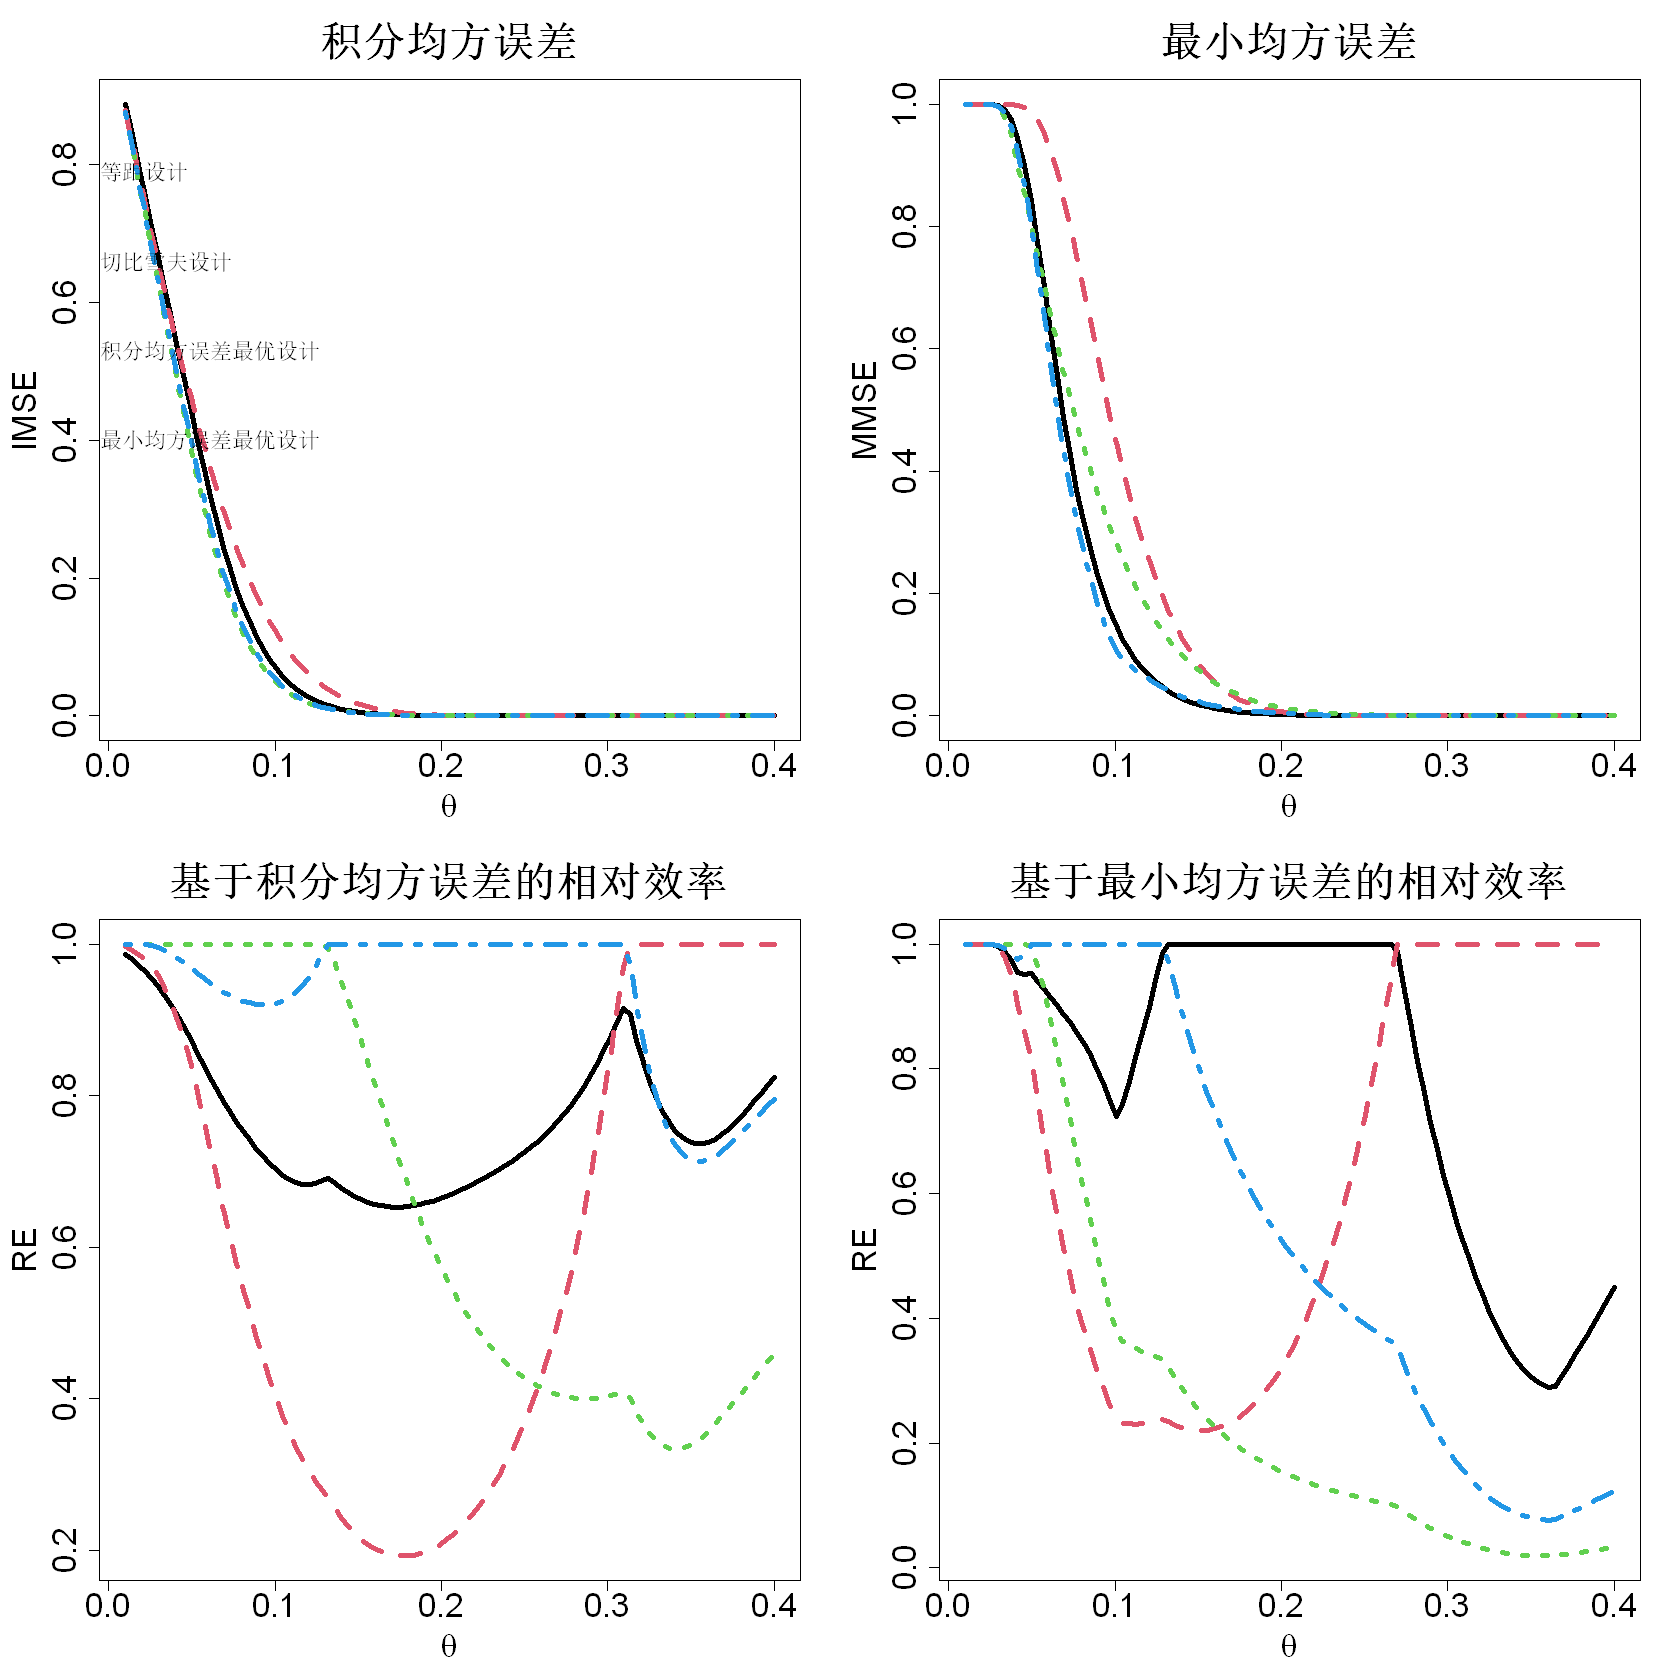

In [4]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/3.3-ev.csv")){
  # <==== 绘图前计算：还原自 rexpdes/R/Ch3.R 图3.3 ====>
  n=10
  theta=.1
  imse=function(D,theta,n){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    L=chol(R+10^(-6)*diag(n))
    r=function(x) exp(-((x-D)/theta)^2)
    s=function(x){
      a=forwardsolve(t(L),r(x))
      return(1-sum(a^2))
    }
    val=integrate(Vectorize(s),0,1,abs.tol=10^(-10))$val
    return(val)
  }
  mmse=function(D,theta,n){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    L=chol(R+10^(-6)*diag(n))
    r=function(x) exp(-((x-D)/theta)^2)
    s=function(x){
      a=forwardsolve(t(L),r(x))
      return(1-sum(a^2))
    }
    test=seq(0,1,length=1001)
    val=apply(cbind(test),1,s)
    return(max(val))
  }
  # 图3.2 中的四种设计 D1-D4
  D1=((1:n)-1)/(n-1)
  d=cos((2*(1:n)-1)/(2*n)*pi)
  D2=(d+1)/2
  D0=((1:n)-.5)/n
  a=optim(D0,imse,theta=theta,n=n,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D3=a$par
  a=optim(D0,mmse,theta=theta,n=n,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D4=a$par
  ev=seq(.01,.4,length=100)
  IR=MR=matrix(0,nrow=100,ncol=4)
  for(i in 1:100){
    theta=ev[i]
    IR[i,]=c(imse(D1,theta,n),imse(D2,theta,n),imse(D3,theta,n),imse(D4,theta,n))
    MR[i,]=c(mmse(D1,theta,n),mmse(D2,theta,n),mmse(D3,theta,n),mmse(D4,theta,n))
  }
  IRR=sweep(IR,1,apply(IR,1,min),"/")
  MRR=sweep(MR,1,apply(MR,1,min),"/")
  out1=cbind(ev,IR,MR,IRR,MRR)
  colnames(out1)=c("ev",paste0("IR.",1:4),paste0("MR.",1:4),paste0("IRR.",1:4),paste0("MRR.",1:4))
  write.csv(out1,file="data/3.3-ev.csv",row.names=FALSE)
}
# <==== 读回绘图 ====>
df_ev=read.csv("data/3.3-ev.csv")
ev=df_ev$ev
IR=as.matrix(df_ev[,paste0("IR.",1:4)])
MR=as.matrix(df_ev[,paste0("MR.",1:4)])
IRR=as.matrix(df_ev[,paste0("IRR.",1:4)])
MRR=as.matrix(df_ev[,paste0("MRR.",1:4)])

options(repr.plot.width=14,repr.plot.height=14)
par(mar=c(5,5,4,2))
par(mfrow=c(2,2))
matplot(ev,IR,type="l",xlab=expression(theta),ylab="IMSE",lwd=4,cex.lab=2,cex.axis=2,main="积分均方误差",cex.main=2.5)
legend("topright",legend=c("等距设计","切比雪夫设计","积分均方误差最优设计","最小均方误差最优设计"),lty=1:4,col=1:4,lwd=4,bty="n",cex=1.5)
matplot(ev,MR,type="l",xlab=expression(theta),ylab="MMSE",lwd=4,cex.lab=2,cex.axis=2,main="最小均方误差",cex.main=2.5)
matplot(ev,1/IRR,type="l",xlab=expression(theta),ylab="RE",lwd=4,cex.lab=2,cex.axis=2,main="基于积分均方误差的相对效率",cex.main=2.5)
matplot(ev,1/MRR,type="l",xlab=expression(theta),ylab="RE",lwd=4,cex.lab=2,cex.axis=2,main="基于最小均方误差的相对效率",cex.main=2.5)
par(mfrow=c(1,1))

> **图 3.4** 在参数 $\theta=0.1$ 的条件下，采用集成均方误差最优设计、最小均方误差最优设计与最大熵设计（蓝色圆点）。

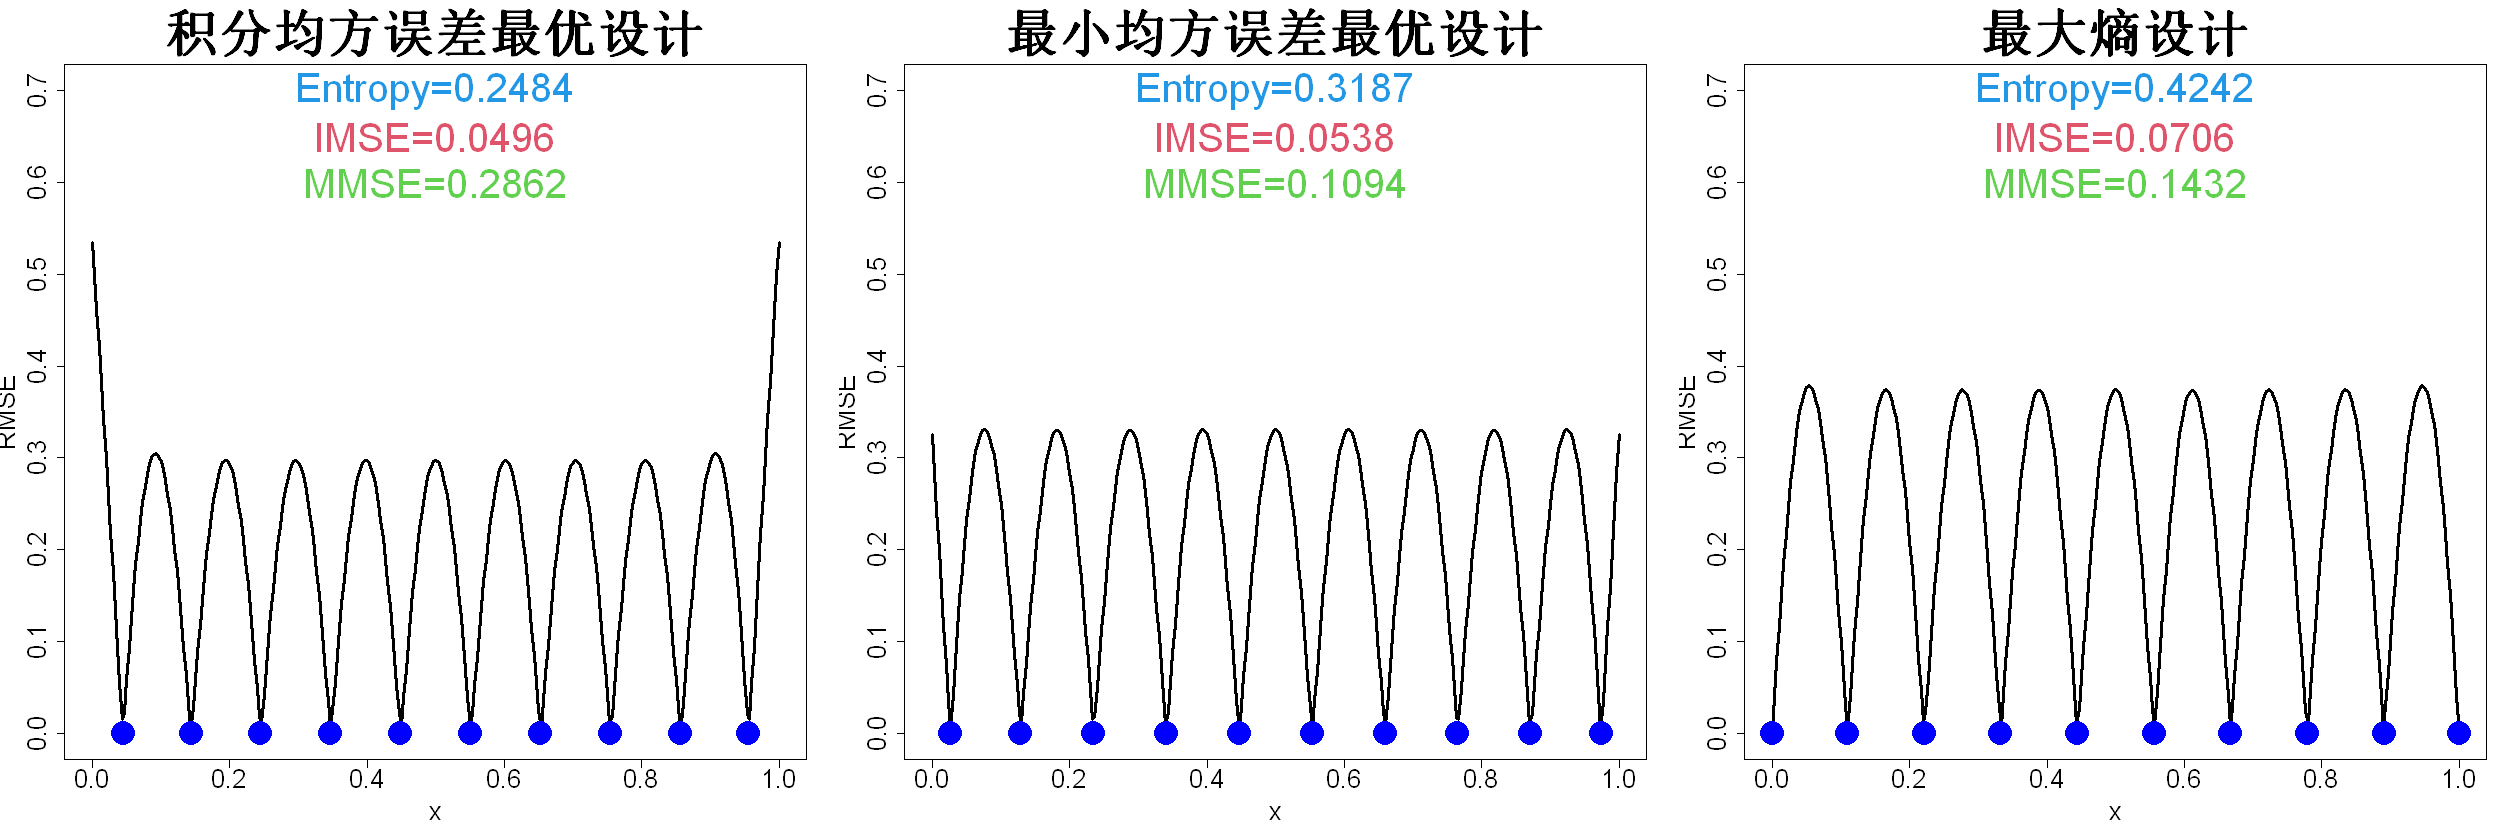

In [5]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/3.4-D.csv")||!file.exists("data/3.4-sa.csv")||!file.exists("data/3.4-round.csv")){
  # <==== 绘图前计算：还原自 rexpdes/R/Ch3.R 图3.4 ====>
  set.seed(1)
  n=10
  theta=.1
  N=301
  test=seq(0,1,length=N)
  imse=function(D,theta,n){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    L=chol(R+10^(-6)*diag(n))
    r=function(x) exp(-((x-D)/theta)^2)
    s=function(x){
      a=forwardsolve(t(L),r(x))
      return(1-sum(a^2))
    }
    val=integrate(Vectorize(s),0,1,abs.tol=10^(-10))$val
    return(val)
  }
  mmse=function(D,theta,n){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    L=chol(R+10^(-6)*diag(n))
    r=function(x) exp(-((x-D)/theta)^2)
    s=function(x){
      a=forwardsolve(t(L),r(x))
      return(1-sum(a^2))
    }
    test=seq(0,1,length=1001)
    val=apply(cbind(test),1,s)
    return(max(val))
  }
  r=function(x,D,theta) exp(-((x-D)/theta)^2)
  s=function(x,D,theta,L){
    a=forwardsolve(t(L),r(x,D,theta))
    return(sqrt(max(1-sum(a^2),0)))
  }
  ent=function(D,theta){
    E=as.matrix(dist(D))
    R=exp(-(E/theta)^2)
    val=det(R)
    return(val)
  }
  negent=function(D,theta) -ent(D,theta)
  # D3：IMSE 最优设计
  D0=((1:n)-.5)/n
  a=optim(D0,imse,theta=theta,n=n,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D=D3=a$par
  E=as.matrix(dist(D3))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa3=apply(cbind(test),1,function(xi) s(xi,D3,theta,L))
  Ent3=ent(D3,theta)
  IMSE3=imse(D3,theta,n)
  MMSE3=mmse(D3,theta,n)
  # D4：MMSE 最优设计
  a=optim(D0,mmse,theta=theta,n=n,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D=D4=a$par
  E=as.matrix(dist(D4))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa4=apply(cbind(test),1,function(xi) s(xi,D4,theta,L))
  Ent4=ent(D4,theta)
  IMSE4=imse(D4,theta,n)
  MMSE4=mmse(D4,theta,n)
  # D5：最大熵设计
  D0=((1:n)-1)/(n-1)
  a=optim(D0,negent,theta=theta,lower=rep(0,n),upper=rep(1,n),method="L-BFGS-B")
  D=D5=a$par
  E=as.matrix(dist(D5))
  R=exp(-(E/theta)^2)
  L=chol(R+10^(-6)*diag(n))
  sa5=apply(cbind(test),1,function(xi) s(xi,D5,theta,L))
  Ent5=ent(D5,theta)
  IMSE5=imse(D5,theta,n)
  MMSE5=mmse(D5,theta,n)
  out1=cbind(D3,D4,D5)
  colnames(out1)=c("D3","D4","D5")
  write.csv(out1,file="data/3.4-D.csv",row.names=FALSE)
  out2=cbind(test,sa3,sa4,sa5)
  colnames(out2)=c("test","sa3","sa4","sa5")
  write.csv(out2,file="data/3.4-sa.csv",row.names=FALSE)
  out3=cbind(theta,Ent3,Ent4,Ent5,IMSE3,IMSE4,IMSE5,MMSE3,MMSE4,MMSE5)
  colnames(out3)=c("theta","Ent3","Ent4","Ent5","IMSE3","IMSE4","IMSE5","MMSE3","MMSE4","MMSE5")
  write.csv(out3,file="data/3.4-round.csv",row.names=FALSE)
}
# <==== 读回绘图 ====>
df_D=read.csv("data/3.4-D.csv")
D3=df_D$D3;D4=df_D$D4;D5=df_D$D5
df_sa=read.csv("data/3.4-sa.csv")
test=df_sa$test;sa3=df_sa$sa3;sa4=df_sa$sa4;sa5=df_sa$sa5
df_r=read.csv("data/3.4-round.csv")
theta=df_r$theta
Ent3=df_r$Ent3;Ent4=df_r$Ent4;Ent5=df_r$Ent5
IMSE3=df_r$IMSE3;IMSE4=df_r$IMSE4;IMSE5=df_r$IMSE5
MMSE3=df_r$MMSE3;MMSE4=df_r$MMSE4;MMSE5=df_r$MMSE5

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(test,sa3,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="积分均方误差最优设计",cex.main=4,cex.lab=2,cex.axis=2,lwd=3)
points(cbind(D3,0),pch=16,col="blue",cex=4)
text(.5,.7,paste0("Entropy=",round(Ent3,4)),cex=3,col=4)
text(.5,.65,paste0("IMSE=",round(IMSE3,4)),cex=3,col=2)
text(.5,.6,paste0("MMSE=",round(MMSE3,4)),cex=3,col=3)
plot(test,sa4,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="最小均方误差最优设计",cex.main=4,cex.lab=2,cex.axis=2,lwd=3)
points(cbind(D4,0),pch=16,col="blue",cex=4)
text(.5,.7,paste0("Entropy=",round(Ent4,4)),cex=3,col=4)
text(.5,.65,paste0("IMSE=",round(IMSE4,4)),cex=3,col=2)
text(.5,.6,paste0("MMSE=",round(MMSE4,4)),cex=3,col=3)
plot(test,sa5,type="l",xlab="x",ylab="RMSE",ylim=c(0,.7),main="最大熵设计",cex.main=4,cex.lab=2,cex.axis=2,lwd=3)
points(cbind(D5,0),pch=16,col="blue",cex=4)
text(.5,.7,paste0("Entropy=",round(Ent5,4)),cex=3,col=4)
text(.5,.65,paste0("IMSE=",round(IMSE5,4)),cex=3,col=2)
text(.5,.6,paste0("MMSE=",round(MMSE5,4)),cex=3,col=3)
par(mfrow=c(1,1))